# ✈️Preserving Heritage and Enhancing Tourism(part2)

Understanding customers (tourists) and their expectations are critical for effective marketing and promotion of tourism. A recommendation engine is an excellent way to supplement existing marketing outreach.This project analyzes tourist destinations in Indonesia using user ratings and descriptions. The goal is to identify which locations and cities are most popular, what types of tourism each location is famous for (e.g., nature, historical, entertainment, shopping, or worship), and understand visitor preferences. Additionally, a collaborative filtering model is developed to recommend other places for tourists based on current visited locations, leveraging user ratings to enhance tourism experience.

In [58]:
# Import the libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [60]:
user_info = pd.read_csv(r"C:\VIDYA JOBS\PURDUE UNIVERSITY\Preserving_Heritage_Enhancing_Tourism\user.csv")

In [61]:
user_info.head()

,User_Id,Location,Age
0,1,"Semarang, Jawa Tengah",20
1,2,"Bekasi, Jawa Barat",21
2,3,"Cirebon, Jawa Barat",23
3,4,"Bekasi, Jawa Barat",21
4,5,"Lampung, Sumatera Selatan",20


In [62]:
tourism_info = pd.read_excel(r"C:\VIDYA JOBS\PURDUE UNIVERSITY\Preserving_Heritage_Enhancing_Tourism\tourism_with_id.xlsx")

In [63]:
tourism_info.head(3)

,Place_Id,Place_Name,Description,Category,City,Price,Rating,Time_Minutes,Coordinate,Lat,Long,Unnamed: 11,Unnamed: 12
0,1,Monumen Nasional,Monumen Nasional atau yang populer disingkat d...,Budaya,Jakarta,20000,4.6,15.0,"{'lat': -6.1753924, 'lng': 106.8271528}",-6.175392,106.827153,NaN,1
1,2,Kota Tua,"Kota tua di Jakarta, yang juga bernama Kota Tu...",Budaya,Jakarta,0,4.6,90.0,"{'lat': -6.137644799999999, 'lng': 106.8171245}",-6.137645,106.817125,NaN,2
2,3,Dunia Fantasi,Dunia Fantasi atau disebut juga Dufan adalah t...,Taman Hiburan,Jakarta,270000,4.6,360.0,"{'lat': -6.125312399999999, 'lng': 106.8335377}",-6.125312,106.833538,NaN,3


In [64]:
tourism_rating = pd.read_csv(r"C:\VIDYA JOBS\PURDUE UNIVERSITY\Preserving_Heritage_Enhancing_Tourism\tourism_rating.csv")

In [65]:
tourism_rating.head(3)

,User_Id,Place_Id,Place_Ratings
0,1,179,3
1,1,344,2
2,1,5,5


#### Analysing user_info dataset

In [76]:
user_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   User_Id   300 non-null    int64 
 1   Location  300 non-null    object
 2   Age       300 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 7.2+ KB


In [77]:
user_info.isnull().sum()

User_Id     0
Location    0
Age         0
dtype: int64

In [78]:
user_info.duplicated().sum()

np.int64(0)

In [79]:
user_info.columns

Index(['User_Id', 'Location', 'Age'], dtype='object')

#### Analysing the tourism_info dataset

In [80]:
tourism_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 437 entries, 0 to 436
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Place_Id      437 non-null    int64  
 1   Place_Name    437 non-null    object 
 2   Description   437 non-null    object 
 3   Category      437 non-null    object 
 4   City          437 non-null    object 
 5   Price         437 non-null    int64  
 6   Rating        437 non-null    float64
 7   Time_Minutes  205 non-null    float64
 8   Coordinate    437 non-null    object 
 9   Lat           437 non-null    float64
 10  Long          437 non-null    float64
 11  Unnamed: 11   0 non-null      float64
 12  Unnamed: 12   437 non-null    int64  
dtypes: float64(5), int64(3), object(5)
memory usage: 44.5+ KB


In [81]:
tourism_info.isnull().sum()

Place_Id          0
Place_Name        0
Description       0
Category          0
City              0
Price             0
Rating            0
Time_Minutes    232
Coordinate        0
Lat               0
Long              0
Unnamed: 11     437
Unnamed: 12       0
dtype: int64

In [82]:
# Dropping the irrelavant columns

tourism_info = tourism_info.drop(columns=["Unnamed: 11","Unnamed: 12"])

In [83]:
tourism_info.columns

Index(['Place_Id', 'Place_Name', 'Description', 'Category', 'City', 'Price',
       'Rating', 'Time_Minutes', 'Coordinate', 'Lat', 'Long'],
      dtype='object')

In [84]:
# Filling the Time_minutes with median value because some places may take a long time to tour and the others less

tourism_info["Time_Minutes"] = tourism_info["Time_Minutes"].fillna(tourism_info["Time_Minutes"].median())

In [85]:
tourism_info.isnull().sum()

Place_Id        0
Place_Name      0
Description     0
Category        0
City            0
Price           0
Rating          0
Time_Minutes    0
Coordinate      0
Lat             0
Long            0
dtype: int64

In [86]:
tourism_info.duplicated().sum()

np.int64(0)

In [87]:
tourism_rating.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   User_Id        10000 non-null  int64
 1   Place_Id       10000 non-null  int64
 2   Place_Ratings  10000 non-null  int64
dtypes: int64(3)
memory usage: 234.5 KB


In [88]:
tourism_rating.isnull().sum()

User_Id          0
Place_Id         0
Place_Ratings    0
dtype: int64

In [89]:
tourism_rating.duplicated().sum()

np.int64(79)

In [90]:
tourism_rating.duplicated(subset=["User_Id","Place_Id","Place_Ratings"]).sum()

np.int64(79)

In [91]:
tourism_rating = tourism_rating.drop_duplicates()

In [92]:
tourism_rating.duplicated().sum()

np.int64(0)

#### Inference:

All the three datasets have been analysed for missing values,duplicates and irrelavant columns and the necessary actions have been taken to analyse the datasets further.

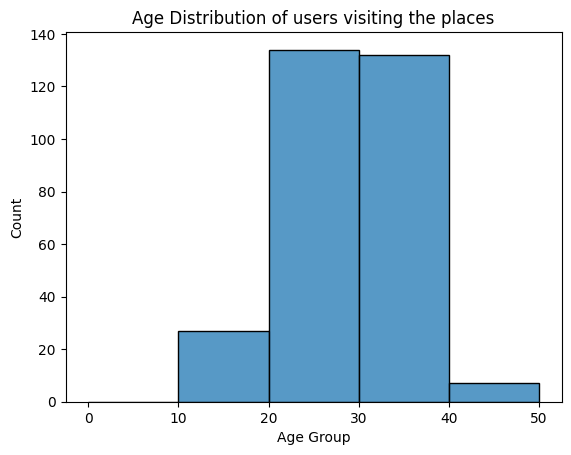

In [93]:
# • Analyzing the age distribution of users visiting the places and rating them

bins=[0,10,20,30,40,50]
sns.histplot(user_info["Age"],bins=bins)
plt.title("Age Distribution of users visiting the places")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.show()

#### Inference: We find that most of visitors are between the ages of 20-40

Location
Bekasi             39
Semarang           22
Lampung            20
Yogyakarta         20
Bogor              17
Cirebon            14
Jakarta Selatan    14
Subang             14
Depok              12
Ponorogo           11
Jakarta Utara      10
Surabaya           10
Jakarta Pusat      10
Sragen              9
Serang              9
Bandung             8
Karawang            8
Kota Gede           8
Tanggerang          8
Jakarta Timur       6
Jakarta Barat       6
Palembang           5
Solo                4
Klaten              4
Cilacap             4
Purwakarat          4
Nganjuk             2
Madura              2
Name: count, dtype: int64


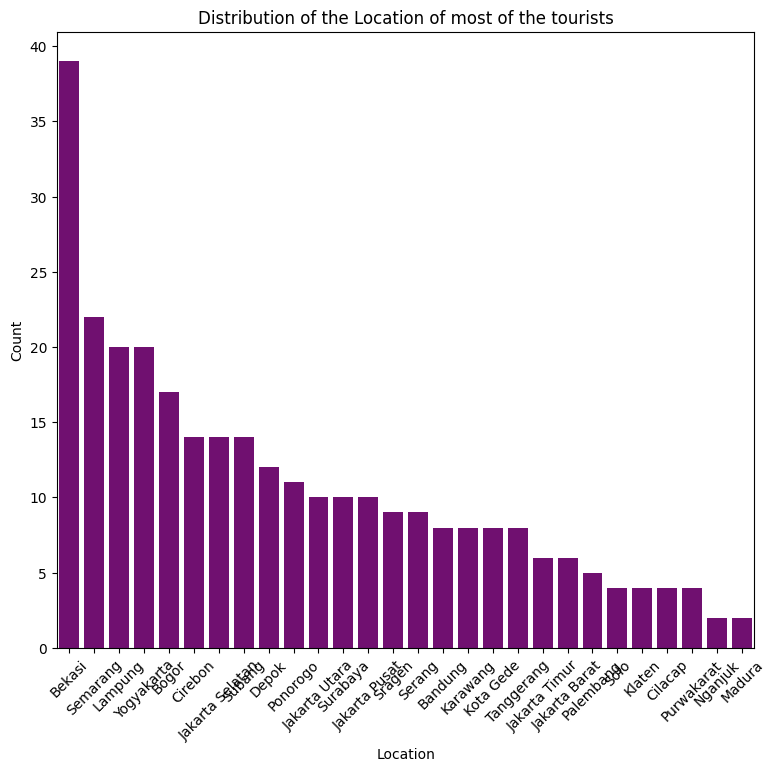

In [166]:
# • Identifying the places where most of these users (tourists) are coming from

user_location = user_info["Location"].str.split(",").str[0]

city_counts = user_location.value_counts()
print(city_counts)
plt.figure(figsize=(9,8))
sns.countplot(x=user_location,color="purple",order=city_counts.index)
plt.title("Distribution of the Location of most of the tourists")
plt.xlabel("Location")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

#### Inference :
We find that most of the tourist are coming from Besaki,Semarang,Lampung,Yogyakarta and Bogor.

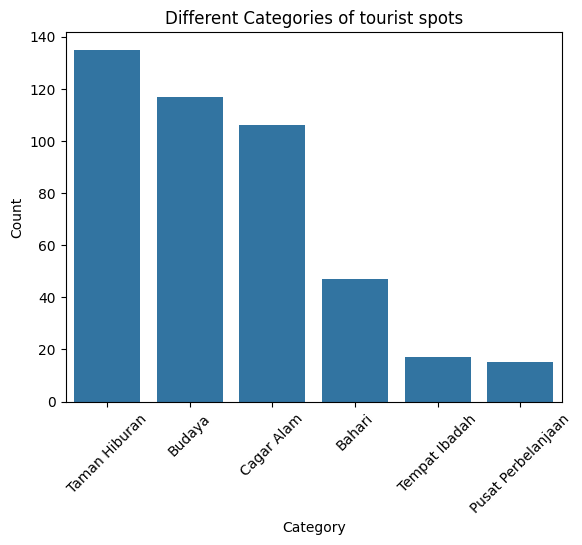

In [95]:
# I. What are the different categories of tourist spots?

sns.barplot(tourism_info["Category"].value_counts())
plt.title("Different Categories of tourist spots")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

#### Inference:

The various categories of tourist spots are Taman Hiburan,Budaya,Cagar Alam,Bahari,Tempat Ibadah and Pusat Perbelanjaan.

In [167]:
# Finding what is most famous or suitable in each location

tourism_info.sample()

,Place_Id,Place_Name,Description,Category,City,Price,Rating,Time_Minutes,Coordinate,Lat,Long
316,317,Curug Cimahi,Curug Cimahi adalah air terjun yang terletak d...,Cagar Alam,Bandung,15000,4.6,30.0,"{'lat': -6.797738300000002, 'lng': 107.5783691}",-6.797738,107.578369


In [229]:
# Using deep-translator
!pip install deep-translator

import warnings
warnings.filterwarnings("ignore")


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [176]:
from deep_translator import GoogleTranslator

def translate_text(text):
    try:
        return GoogleTranslator(source="id",target="en").translate(str(text))
    except:
        return text

tourism_info["Description_English"] = tourism_info["Description"].apply(translate_text)

print(tourism_info["Description_English"].head(1))

0    The National Monument or what is popularly abb...
Name: Description_English, dtype: object


In [182]:
# Defining the keywords based on the category

category_keywords = {
    "Historical/Cultural": ["museum", "history", "cultural", "monument", "temple", "heritage", "castle", "palace"],
    "Nature": ["forest", "mountain", "waterfall", "park", "island", "beach", "nature", "snorkeling", "diving"],
    "Entertainment/Amusement": ["amusement", "theme park", "rides", "fun", "entertainment", "playground", "recreation"],
    "Shopping/Mall": ["mall", "shopping", "market", "bazaar", "store", "plaza"],
    "Religious/Worship": ["mosque", "church", "temple", "worship", "prayer", "religious"]
}

In [183]:
# Defining a function to extract the category based on keywords

def classify_text(text):
    text = str(text).lower()

    scores = {cat : 0 for cat in category_keywords}

    for category,keywords in category_keywords.items():
        for word in keywords:
            if word in text:
                scores[category] += 1

    best_category = max(scores,key=scores.get)

    if scores[best_category] == 0:
        return "Unknown"

    return best_category

In [187]:
tourism_info["Tourism_Type"] = tourism_info["Description_English"].apply(classify_text)

In [193]:
tourism_info.sample()

,Place_Id,Place_Name,Description,Category,City,Price,Rating,Time_Minutes,Coordinate,Lat,Long,Description_English,NLP_classification,Tourism_Type
98,99,Kampung Wisata Kadipaten,Kampung Wisata Kadipaten secaara kewilayahan b...,Budaya,Yogyakarta,0,4.4,60.0,"{'lat': -7.806093000000001, 'lng': 110.35831}",-7.806093,110.35831,The Kadipaten Tourism Village is regionally lo...,Historical/Cultural,Historical/Cultural


In [194]:
tourism_info = tourism_info.drop("NLP_classification",axis=1)

In [195]:
tourism_info.sample()

,Place_Id,Place_Name,Description,Category,City,Price,Rating,Time_Minutes,Coordinate,Lat,Long,Description_English,Tourism_Type
129,130,Studio Alam Gamplong,Studio Gamplong atau Studio Alam Gamplong adal...,Taman Hiburan,Yogyakarta,10000,4.4,120.0,"{'lat': -7.805793599999998, 'lng': 110.2367304}",-7.805794,110.23673,Gamplong Studio or Gamplong Nature Studio is a...,Nature


In [204]:
# The kind of tourism each location is famous 

location_tourism_type = tourism_info.groupby(["Category","Tourism_Type"]).size().reset_index(name="Count")

famous_per_category = location_tourism_type.loc[location_tourism_type.groupby("Category")["Count"].idxmax()]
print(famous_per_category)

              Category         Tourism_Type  Count
1               Bahari               Nature     46
3               Budaya  Historical/Cultural     91
10          Cagar Alam               Nature     65
17  Pusat Perbelanjaan        Shopping/Mall      7
21       Taman Hiburan               Nature     61
26       Tempat Ibadah    Religious/Worship     14


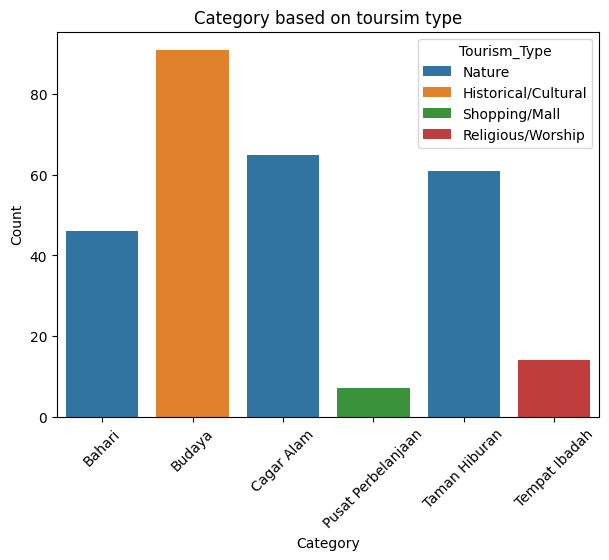

In [211]:
# Plotting the famous tourism type for category

plt.figure(figsize=(7,5))
sns.barplot(x="Category",y="Count",data=famous_per_category,hue="Tourism_Type")
plt.title("Category based on toursim type")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


#### Inference:

The tourism descriptions in Malay were first translated into English using a translation model. Then, an NLP-based keyword extraction approach was applied to classify each destination into tourism categories such as entertainment, cultural, nature, and religious. This enabled analysis of the most suitable tourism type for each category.

In [228]:
# Which city would be the best for a nature enthusiast to visit?

tourism_per_city = tourism_info.groupby(["City","Tourism_Type"]).size().reset_index(name="Count")


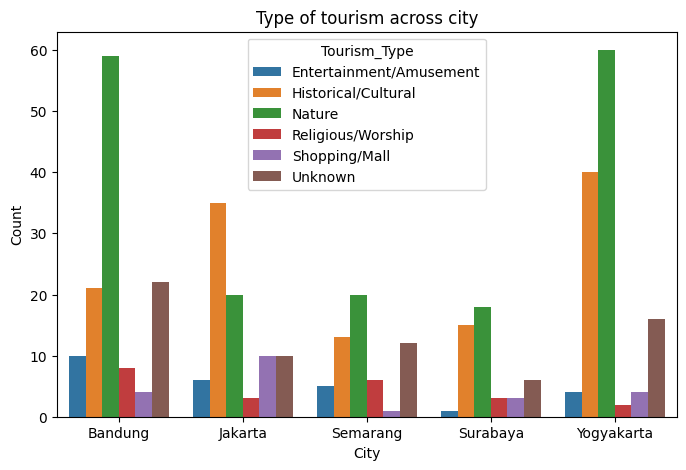

In [227]:
# Plotting which city is best for a nature enthusiast to visit

plt.figure(figsize=(8,5))
sns.barplot(x="City",y="Count",hue="Tourism_Type",data=tourism_per_city)
plt.title("Type of tourism across city")
plt.xlabel("City")
plt.ylabel("Count")
plt.show()

#### Inference:

The best city for nature enthusiast to visit is Yogyakarta followed closely by Bandung.

In [117]:
tourism_rating.head(3)

,User_Id,Place_Id,Place_Ratings
0,1,179,3
1,1,344,2
2,1,5,5


In [118]:
tourism_info.head(1)

,Place_Id,Place_Name,Description,Category,City,Price,Rating,Time_Minutes,Coordinate,Lat,Long
0,1,Monumen Nasional,Monumen Nasional atau yang populer disingkat d...,Budaya,Jakarta,20000,4.6,15.0,"{'lat': -6.1753924, 'lng': 106.8271528}",-6.175392,106.827153


In [141]:
# Creating a combined_dataset to analyse further

combined_dataset = pd.merge(tourism_rating,tourism_info,on="Place_Id")

In [143]:
combined_dataset.head(3)

,User_Id,Place_Id,Place_Ratings,Place_Name,Description,Category,City,Price,Rating,Time_Minutes,Coordinate,Lat,Long
0,1,179,3,Candi Ratu Boko,Situs Ratu Baka atau Candi Boko (Hanacaraka:Í¶...,Budaya,Yogyakarta,75000,4.6,90.0,"{'lat': -7.7705416, 'lng': 110.4894158}",-7.770542,110.489416
1,1,344,2,Pantai Marina,Pantai Marina (bahasa Jawa: Í¶•Í¶±Í¶∂Í¶±Í¶∂Í¶Ç...,Bahari,Semarang,3000,4.1,60.0,"{'lat': -6.948877, 'lng': 110.3893285}",-6.948877,110.389329
2,1,5,5,Atlantis Water Adventure,Atlantis Water Adventure atau dikenal dengan A...,Taman Hiburan,Jakarta,94000,4.5,60.0,"{'lat': -6.12419, 'lng': 106.839134}",-6.124190,106.839134


In [145]:
combined_dataset = combined_dataset[["User_Id","Place_Id","Place_Ratings","Place_Name","Category","City","Price","Rating"]]

In [146]:
combined_dataset.sample()

,User_Id,Place_Id,Place_Ratings,Place_Name,Category,City,Price,Rating
1341,42,386,2,Air Terjun Semirang,Cagar Alam,Semarang,9000,4.4


#### Inference:

The data is consolidated from two datasets and only the relavant columns are kept.
Place_rating specifies the user_rating on a particular place(used for recommendation system) and Rating specifies the overall average rating.

In [139]:
# Use this data to figure out the spots that are most loved by the tourists. Also, which city has the most loved tourist spots?

most_loved_spots = combined_dataset.groupby("City")["Place_Ratings"].mean().sort_values(ascending=False)
print(most_loved_spots)

City
Yogyakarta    3.104986
Bandung       3.079022
Surabaya      3.078035
Semarang      3.035850
Jakarta       3.007361
Name: Place_Ratings, dtype: float64


#### Inference:

1. Yogyakarta seems to be having the highest average rating so it is considered the most loved tourist spot.
2. Bandung,Surabaya follow closely. Jakarat has the average lowest rating.

In [140]:
# which Category of places are users liking the most?

most_loved_category = combined_dataset.groupby("Category")["Place_Ratings"].mean().sort_values(ascending=False)
print(most_loved_category)

Category
Taman Hiburan         3.118386
Tempat Ibadah         3.086387
Cagar Alam            3.081352
Budaya                3.032270
Bahari                3.011194
Pusat Perbelanjaan    2.947507
Name: Place_Ratings, dtype: float64


#### Inference:

1. Taman Hiburan (Amusement / Entertainment) is the most loved category.
2. Tempat Ibadah (Places of Worship) and Cagar Alam (Nature) are also highly rated.
3. Budaya (Cultural) and Bahari (Beach / Marine) have moderate ratings.
4. Pusat Perbelanjaan (Shopping Centers) is the least liked category in terms of average user ratings.

## Collaborative filtering model for recommendation.

Collaborative filtering is the common method used in recommendation systems.
There are different types of collaborative filtering:
1. User-User Collaborative Filtering
2. Item-Item Collaborative Filtering

In this project we want to recommend other places to visit using the current tourist location (place name).
Steps involved:
1. Prepare the data
2. Compute item similarity
3. Recommend Places


In [164]:
combined_dataset.sample()

,User_Id,Place_Id,Place_Ratings,Place_Name,Category,City,Price,Rating
4139,127,389,2,Brown Canyon,Cagar Alam,Semarang,0,4.2


In [154]:
from sklearn.metrics.pairwise import cosine_similarity

# Creating the user-item matrix

user_item_matrix = combined_dataset.pivot_table(
    index = "User_Id",columns="Place_Name",values="Place_Ratings")

In [151]:
# Filling missing values with 0

matrix_filled = user_item_matrix.fillna(0)

In [157]:
# Transposing the matrix
item_similarity = cosine_similarity(matrix_filled.T)

In [159]:
# Converting to DataFrame 

item_similarity_df = pd.DataFrame(item_similarity,index=user_item_matrix.columns,columns=user_item_matrix.columns)

In [161]:
item_similarity_df.head(3)

Place_Name,Air Mancur Menari,Air Terjun Kali Pancur,Air Terjun Kedung Pedut,Air Terjun Semirang,Air Terjun Sri Gethuk,Alive Museum Ancol,Alun Alun Selatan Yogyakarta,Alun-Alun Kota Bandung,Alun-alun Utara Keraton Yogyakarta,Amazing Art World,...,Wisata Alam Wana Wisata Penggaron,Wisata Batu Kuda,Wisata Eling Bening,Wisata Kaliurang,Wisata Kampung Krisan Clapar,Wisata Kraton Jogja,Wisata Kuliner Pecenongan,Wisata Lereng Kelir,Wisata Mangrove Tapak,Wot Batu
Place_Name,,,,,,,,,,,,,,,,,,,,,
Air Mancur Menari,1.000000,0.000000,0.096964,0.000000,0.01949,0.000000,0.053606,0.000000,0.000000,0.152254,...,0.00000,0.000000,0.110482,0.111740,0.021363,0.049629,0.131369,0.076108,0.000000,0.000000
Air Terjun Kali Pancur,0.000000,1.000000,0.041091,0.031167,0.03091,0.023378,0.045778,0.072384,0.088857,0.005866,...,0.18277,0.102458,0.109176,0.055962,0.221532,0.000000,0.016723,0.114901,0.041823,0.196703
Air Terjun Kedung Pedut,0.096964,0.041091,1.000000,0.018004,0.03846,0.000000,0.250346,0.058540,0.000000,0.147059,...,0.00000,0.024859,0.052323,0.057445,0.168625,0.073450,0.192732,0.067583,0.101474,0.018716


In [165]:
# Function to recommend similar places

def recommend_places(current_place,top_places=5):
    if current_place not in item_similarity_df.columns:
        return "Place not in dataframe"

    similar_places = item_similarity_df[current_place].sort_values(ascending=False)
    similar_places = similar_places.drop(current_place)

    return similar_places.head(top_places)

recommendations = recommend_places("Brown Canyon")
print(recommendations)      

Place_Name
Pulau Semak Daun                     0.371912
Pantai Baron                         0.258523
Hutan Mangrove Kulon Progo           0.242010
Orchid Forest Cikole                 0.234138
Gereja Tiberias Indonesia Bandung    0.210679
Name: Brown Canyon, dtype: float64


#### Inference:

If a tourist visits Brown Canyon, the system recommends Pulau Semak Daun, Pantai Baron, Hutan Mangrove Kulon Progo, Orchid Forest Cikole, and Gereja Tiberias Indonesia Bandung.The higher the values higher the similarity.

# Conclusion:
The analysis revealed the most loved tourist spots and the dominant tourism types in each city and category. Nature tourism dominates cities like Yogyakarta and Bandung, while historical/cultural tourism is most common in Jakarta. Using the user-place ratings, a collaborative filtering recommendation system successfully suggests other relevant tourist spots to visitors. These insights can help travelers plan visits and support tourism planning by highlighting popular locations and experiences.